# LSTM para previsão do fechamento do Bitcoin (2017–2023)

Antonio Carolino,
Beatriz Mergulhão,
Luiza Trigueiro,
João Ebbers

Contém: split temporal 80/20, normalização correta, criação de janelas, modelo LSTM, métricas (MSE, RMSE, MAE, POCID) e baseline.

In [ ]:
#@title Primeiro Trial
- Ajustes de Parâmetros e Window


In [ ]:

import numpy as np
import pandas as pd
import random, os, time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import io
import matplotlib.pyplot as plt

In [ ]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [ ]:

#@title Hyperpameters
window_size = 30
batch_size = 32
epochs = 50
lstm_units = 64
dropout_rate = 0.1
learning_rate = 1e-4


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data-bitcoin_timedata_v2.csv to data-bitcoin_timedata_v2.csv


In [ ]:
file_name = list(uploaded.keys())[0]
print("Reading file:", file_name)

try:
    bitcoin = pd.read_csv(io.StringIO(uploaded[file_name].decode('utf-8')))
except UnicodeDecodeError:
    bitcoin = pd.read_csv(io.BytesIO(uploaded[file_name]))

bitcoin.head()
col_target = [c for c in bitcoin.columns if 'close' in c.lower()][0]
serie = bitcoin[[col_target]].sort_index()
serie.head()

Reading file: data-bitcoin_timedata_v2.csv


,close
0,4285.08
1,4108.37
2,4139.98
3,4086.29
4,4016.00


In [ ]:
#@title Train x Test
split = int(len(serie) * 0.8)
train = serie.iloc[:split].copy()
test  = serie.iloc[split:].copy()

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 1740, Test size: 436


In [ ]:
#@title Data normalization
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)

In [ ]:
#@title Windows
def create_sequences_from_array(values, window):
    X, y = [], []
    v = np.asarray(values).reshape(-1)
    for i in range(len(v) - window):
        X.append(v[i:i+window])
        y.append(v[i+window])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32).reshape(-1,1)
    return X, y

X_train, y_train = create_sequences_from_array(train_scaled, window_size)
X_test,  y_test  = create_sequences_from_array(test_scaled,  window_size)

X_train = X_train.reshape(-1, window_size, 1)
X_test  = X_test.reshape(-1, window_size, 1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


X_train: (1710, 30, 1) y_train: (1710, 1)
X_test : (406, 30, 1) y_test : (406, 1)


In [ ]:
#@title Placeholders
def build_lstm(window, units=64, dropout=0.1):
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layers.LSTM(units, activation='tanh'),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

model = build_lstm(window_size, lstm_units, dropout_rate)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title Training the Network
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/50
49/49 - 3s - 66ms/step - loss: 0.0956 - val_loss: 0.1763 - learning_rate: 1.0000e-04
Epoch 2/50
49/49 - 1s - 16ms/step - loss: 0.0314 - val_loss: 0.0050 - learning_rate: 1.0000e-04
Epoch 3/50
49/49 - 1s - 16ms/step - loss: 0.0061 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 4/50
49/49 - 1s - 15ms/step - loss: 0.0035 - val_loss: 0.0038 - learning_rate: 1.0000e-04
Epoch 5/50
49/49 - 1s - 16ms/step - loss: 0.0033 - val_loss: 0.0043 - learning_rate: 1.0000e-04
Epoch 6/50
49/49 - 1s - 16ms/step - loss: 0.0026 - val_loss: 0.0039 - learning_rate: 1.0000e-04
Epoch 7/50
49/49 - 1s - 25ms/step - loss: 0.0025 - val_loss: 0.0037 - learning_rate: 1.0000e-04
Epoch 8/50
49/49 - 1s - 15ms/step - loss: 0.0027 - val_loss: 0.0039 - learning_rate: 5.0000e-05
Epoch 9/50
49/49 - 1s - 29ms/step - loss: 0.0026 - val_loss: 0.0037 - learning_rate: 5.0000e-05
Epoch 10/50
49/49 - 1s - 25ms/step - loss: 0.0025 - val_loss: 0.0036 - learning_rate: 5.0000e-05
Epoch 11/50
49/49 - 1s - 25ms/step - lo

In [ ]:
y_pred_scaled = model.predict(X_test)
y_true = scaler.inverse_transform(y_test)
y_pred = scaler.inverse_transform(y_pred_scaled)

y_naive_scaled = X_test[:, -1, 0].reshape(-1,1)
y_naive = scaler.inverse_transform(y_naive_scaled)

mse_lstm = mean_squared_error(y_true, y_pred)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_true, y_pred)

mse_naive = mean_squared_error(y_true, y_naive)
rmse_naive = np.sqrt(mse_naive)
mae_naive = mean_absolute_error(y_true, y_naive)

def sign_dir(a, b):
    diff = a - b
    return np.sign(diff).astype(int)

dir_true = sign_dir(y_true, y_naive)
dir_pred = sign_dir(y_pred, y_naive)
dir_naive = sign_dir(y_naive, y_naive)

pocid_lstm = (dir_true == dir_pred).mean() * 100
pocid_naive = (dir_true == dir_naive).mean() * 100

print("RESULTS:")
print(f"LSTM  - MSE: {mse_lstm:.4f}, RMSE: {rmse_lstm:.4f}, MAE: {mae_lstm:.4f}, POCID: {pocid_lstm:.2f}%")
print(f"Naive - MSE: {mse_naive:.4f}, RMSE: {rmse_naive:.4f}, MAE: {mae_naive:.4f}, POCID: {pocid_naive:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
RESULTS:
LSTM  - MSE: 2893417.5000, RMSE: 1701.0049, MAE: 1324.4114, POCID: 54.43%
Naive - MSE: 356869.4688, RMSE: 597.3855, MAE: 402.3701, POCID: 0.00%


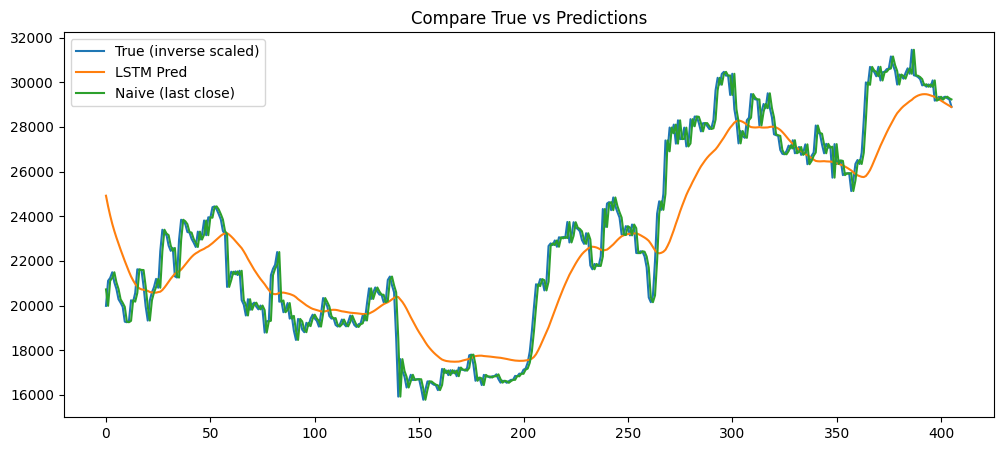

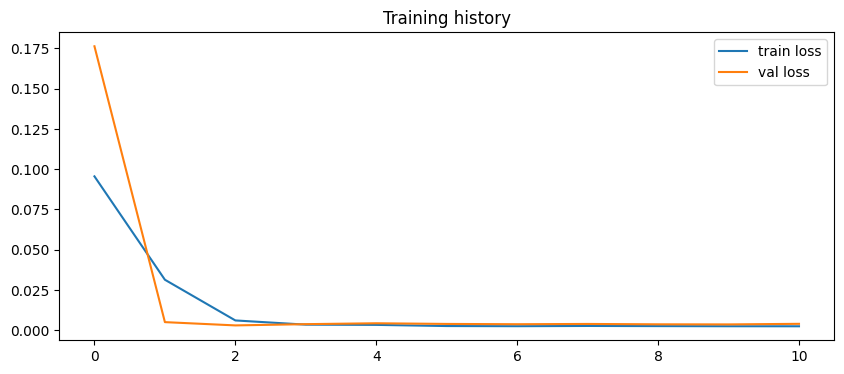

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_true, label='True (inverse scaled)')
plt.plot(y_pred, label='LSTM Pred')
plt.plot(y_naive, label='Naive (last close)')
plt.title('Compare True vs Predictions')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Training history')
plt.legend(); plt.show()

In [ ]:
#@title Segundo Trial





# LSTM — Bitcoin Log-Return Forecasting
Pipeline ajustado para melhorar estabilidade de treino e interpretabilidade:
- **Alvo**: log-returns (não preço)
- **Split temporal** 80/20 (sem embaralhar)
- **Scaler**: fit só no treino
- **Validação** + **EarlyStopping** + **ReduceLROnPlateau**
- **Métricas** de regressão (RMSE/MAE) e **classificação de direção** (accuracy, report, confusion matrix)


In [ ]:

#@title Configurações
DATA_PATH = "data-bitcoin_timedata_v2.csv"
OUTPUT_METRICS_CSV = "antonio_lstm_metrics.csv"
SAVE_FIGS = True
FIG_DIR = "figs_antonio_fixed"


In [ ]:

import os, random, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, classification_report)

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger

# Seeds para reprodutibilidade
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)


In [ ]:

#@title Hiperparâmetros
window_size   = 7
horizon       = 1
batch_size    = 256
learning_rate = 3e-4
epochs        = 150
direction_thr = 0.002  # ~0.2% (limiar para classificação de direção)

print(dict(window_size=window_size, horizon=horizon, batch_size=batch_size,
           learning_rate=learning_rate, epochs=epochs, direction_thr=direction_thr))



## 1) Carregar dados e construir **log-returns**
O alvo será `log(price_t) - log(price_{t-1})`, que já está em escala aproximadamente percentual.


In [ ]:

df = pd.read_csv(DATA_PATH)

# Detectar coluna de preço de fechamento
if 'Close' in df.columns:
    price_col = 'Close'
elif 'close' in df.columns:
    price_col = 'close'
elif 'closeUSD' in df.columns:
    price_col = 'closeUSD'
else:
    # usa a última coluna numérica como fallback
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if not num_cols:
        raise ValueError("Nenhuma coluna numérica encontrada no CSV.")
    price_col = num_cols[-1]

price = df[price_col].astype(float).reset_index(drop=True)
logret = np.log(price) - np.log(price.shift(1))
logret = logret.dropna().reset_index(drop=True)

print("Preço:", price_col, " | len price:", len(price), " | len logret:", len(logret))
logret.head()



## 2) Split temporal 80/20 e **scaling** (fit no treino)
Usamos `RobustScaler` por ser menos sensível a outliers em retornos.


In [ ]:

n = len(logret)
n_train = int(n * 0.8)

train_vals = logret.iloc[:n_train].values.reshape(-1, 1)
test_vals  = logret.iloc[n_train:].values.reshape(-1, 1)

scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_vals)
test_scaled  = scaler.transform(test_vals)

print("Tamanhos -> treino:", train_scaled.shape[0], "teste:", test_scaled.shape[0])



## 3) Janelamento com horizonte
Gera pares (X, y), onde **y** é o retorno em *t + horizon*.


In [ ]:

def make_windows_h(arr_scaled, win, horizon=1):
    X, y = [], []
    L = len(arr_scaled)
    for i in range(win, L - horizon + 1):
        X.append(arr_scaled[i-win:i, 0])
        y.append(arr_scaled[i + horizon - 1, 0])
    X = np.array(X).reshape(-1, win, 1)
    y = np.array(y)
    return X, y

# Para montar o conjunto de teste corretamente, concatenamos uma cauda do treino
# para fornecer a janela inicial do bloco de teste.
X_train, y_train = make_windows_h(train_scaled, window_size, horizon=horizon)

tail = train_scaled[-window_size:]
test_concat = np.vstack([tail, test_scaled])
X_test, y_test = make_windows_h(test_concat, window_size, horizon=horizon)

print("Shapes -> X_train:", X_train.shape, "| y_train:", y_train.shape,
      "| X_test:", X_test.shape, "| y_test:", y_test.shape)



## 4) Baseline Naïve (retorno)
Previsão = **último retorno da janela**.


In [ ]:

y_naive_test_scaled = X_test[:, -1, 0]  # último retorno observado
# Inverter para escala original de retorno
def inv_scale(x):
    try:
        return scaler.inverse_transform(x.reshape(-1,1)).reshape(-1)
    except Exception:
        # Caso scaler tenha escala 1D, tratar
        return scaler.inverse_transform(x.reshape(-1,1)).ravel()

y_true = inv_scale(y_test)
y_pred_naive = inv_scale(y_naive_test_scaled)

def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))
def mae(a,b):  return float(np.mean(np.abs(a-b)))
def pocid(y, yhat):
    if len(y) < 2: return np.nan
    return 100.0 * np.mean(np.sign(np.diff(y)) == np.sign(np.diff(yhat)))
print({
    "RMSE_naive": rmse(y_true, y_pred_naive),
    "MAE_naive":  mae(y_true, y_pred_naive),
    "POCID_naive%": pocid(y_true, y_pred_naive)
})


## 5) Modelo LSTM (sem Dropout)


In [ ]:

def build_lstm_model(n_layers:int, lstm_units:int, input_shape):
    model = models.Sequential()
    for i in range(n_layers):
        model.add(layers.LSTM(
            lstm_units, return_sequences=(i < n_layers-1),
            input_shape=input_shape if i==0 else None
        ))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

n_layers = 2
lstm_units = 64
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_lstm_model(n_layers, lstm_units, input_shape)
_ = model.summary()


## 6) Validação temporal + Treino (com **verbose** e *callbacks*)


In [ ]:

# Split do conjunto de treino em (train, val) usando o final do treino como validação
n_tr = X_train.shape[0]
n_val = max(1, int(n_tr * 0.1))
X_tr,  y_tr  = X_train[:-n_val], y_train[:-n_val]
X_val, y_val = X_train[-n_val:], y_train[-n_val:]

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    CSVLogger("treino_log.csv", append=False)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    callbacks=callbacks
)



## 7) Curvas de treino


In [ ]:

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="train loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="val loss")
plt.legend(); plt.title("Loss por época"); plt.xlabel("época"); plt.ylabel("loss"); plt.tight_layout()
plt.show()

if "mae" in history.history:
    plt.figure(figsize=(8,4))
    plt.plot(history.history["mae"], label="train MAE")
    if "val_mae" in history.history:
        plt.plot(history.history["val_mae"], label="val MAE")
    plt.legend(); plt.title("MAE por época"); plt.xlabel("época"); plt.ylabel("MAE"); plt.tight_layout()
    plt.show()



## 8) Previsão no teste e métricas de regressão


In [ ]:

# Previsões em escala normalizada e inversão para escala de retorno
y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1)
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).reshape(-1)

rmse_lstm = rmse(y_true, y_pred)
mae_lstm  = mae(y_true, y_pred)
pocid_lstm = pocid(y_true, y_pred)


print({"RMSE_LSTM": rmse_lstm, "MAE_LSTM": mae_lstm, "POCID_LSTM": pocid_lstm})



## 9) Real vs Previsto (retornos)


In [ ]:

plt.figure(figsize=(10,4))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Previsto")
plt.legend(); plt.title("Retornos: Real vs Previsto"); plt.tight_layout()
plt.show()


In [ ]:
#@title Terceiro Trial

#Experimentos de Regularização L2, Extensões para LSTM e aumento de epocas com earlyStop em Séries Temporais de Bitcoin
Este notebook implementa a Parte final dos experimentos com modelos LSTM para previsão de preços de Bitcoin, consolidando as melhores configurações obtidas nas etapas anteriores e explorando duas direções complementares: regularização determinística e extensões arquiteturais.​

Contexto e Configuração Base
Nas etapas anteriores, foram estabelecidos os seguintes hiperparâmetros ótimos através de tuning sistemático:​

window_size: 30 (baseline)

batch_size: 32 exemplos por batch

learning_rate: 1e-4 (com ReduceLROnPlateau)

epochs: 50 (com Early Stopping monitorando validation loss)

Melhor arquitetura: 2 camadas LSTM, 96 unidades, dropout 0.0

Esta configuração alcançou RMSE de 54.92 e MAE de 43.44, superando significativamente o baseline Naïve (RMSE: 69.49, MAE: 57.60).

In [ ]:

import numpy as np
import pandas as pd
import random, os, time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import io
import matplotlib.pyplot as plt

In [ ]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [ ]:

#@title Hyperpameters Baseline
window_size = 30
batch_size = 32
epochs = 100
lstm_units = 96
dropout_rate = 0.0
learning_rate = 1e-4


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
file_name = list(uploaded.keys())[0]
print("Reading file:", file_name)

try:
    bitcoin = pd.read_csv(io.StringIO(uploaded[file_name].decode('utf-8')))
except UnicodeDecodeError:
    bitcoin = pd.read_csv(io.BytesIO(uploaded[file_name]))

bitcoin.head()
col_target = [c for c in bitcoin.columns if 'close' in c.lower()][0]
serie = bitcoin[[col_target]].sort_index()
serie.head()

In [ ]:
#@title Train x Test
split = int(len(serie) * 0.8)
train = serie.iloc[:split].copy()
test  = serie.iloc[split:].copy()

print(f"Train size: {len(train)}, Test size: {len(test)}")

In [ ]:
#@title Data normalization
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)

In [ ]:
#@title Windows
def create_sequences_from_array(values, window):
    X, y = [], []
    v = np.asarray(values).reshape(-1)
    for i in range(len(v) - window):
        X.append(v[i:i+window])
        y.append(v[i+window])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32).reshape(-1,1)
    return X, y

X_train, y_train = create_sequences_from_array(train_scaled, window_size)
X_test,  y_test  = create_sequences_from_array(test_scaled,  window_size)

X_train = X_train.reshape(-1, window_size, 1)
X_test  = X_test.reshape(-1, window_size, 1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


In [ ]:
#@title Placeholders
def build_lstm(window, units=64, dropout=0.1):
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layers.LSTM(units, activation='tanh'),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

model = build_lstm(window_size, lstm_units, dropout_rate)
model.summary()


In [ ]:
#@title Training the Network
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2
)

In [ ]:
y_pred_scaled = model.predict(X_test)
y_true = scaler.inverse_transform(y_test)
y_pred = scaler.inverse_transform(y_pred_scaled)

y_naive_scaled = X_test[:, -1, 0].reshape(-1,1)
y_naive = scaler.inverse_transform(y_naive_scaled)

mse_lstm = mean_squared_error(y_true, y_pred)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_true, y_pred)

mse_naive = mean_squared_error(y_true, y_naive)
rmse_naive = np.sqrt(mse_naive)
mae_naive = mean_absolute_error(y_true, y_naive)

def sign_dir(a, b):
    diff = a - b
    return np.sign(diff).astype(int)

dir_true = sign_dir(y_true, y_naive)
dir_pred = sign_dir(y_pred, y_naive)
dir_naive = sign_dir(y_naive, y_naive)

pocid_lstm = (dir_true == dir_pred).mean() * 100
pocid_naive = (dir_true == dir_naive).mean() * 100

print("RESULTS:")
print(f"LSTM  - MSE: {mse_lstm:.4f}, RMSE: {rmse_lstm:.4f}, MAE: {mae_lstm:.4f}, POCID: {pocid_lstm:.2f}%")
print(f"Naive - MSE: {mse_naive:.4f}, RMSE: {rmse_naive:.4f}, MAE: {mae_naive:.4f}, POCID: {pocid_naive:.2f}%")

In [ ]:
def plot_results(series, scaler, y_train_inv, y_train_pred_inv,
                 y_test_inv, y_test_pred_inv, window_size, train_cut):
    n_total = len(series)
    series_scaled = scaler.transform(series)
    series_inv = scaler.inverse_transform(series_scaled)
    pred_plot = np.full((n_total, 1), np.nan)

    train_sample_cut = len(y_train_inv)
    # Adjusting for window_size offset for plotting training predictions
    for i in range(train_sample_cut):
        pred_plot[i + window_size, 0] = y_train_pred_inv[i, 0]

    # Adjusting for window_size offset and train set length for plotting test predictions
    for i in range(len(y_test_inv)):
        global_i = i + train_sample_cut + window_size
        if global_i < n_total:
            pred_plot[global_i, 0] = y_test_pred_inv[i, 0]

    plt.figure(figsize=(14, 6))
    plt.plot(series_inv, label='Original (Close)', linewidth=1)
    plt.plot(pred_plot, label='Predições', linewidth=1)
    plt.legend()
    plt.title('Fechamento real vs predito (LSTM)')
    plt.xlabel('Tempo')
    plt.ylabel('Preço')
    plt.show()

# Calculate predictions for the training set
y_train_pred_scaled = model.predict(X_train)
y_train_pred = scaler.inverse_transform(y_train_pred_scaled)
y_train_true_inv = scaler.inverse_transform(y_train)

# The variables y_true (y_test_inv) and y_pred (y_test_pred_inv) are already calculated

plot_results(serie, scaler, y_train_true_inv, y_train_pred, y_true, y_pred, window_size, split)

In [ ]:
y_train_pred_scaled = model.predict(X_train)
y_train_pred = scaler.inverse_transform(y_train_pred_scaled)
y_train_true_inv = scaler.inverse_transform(y_train)

mse_lstm_train = mean_squared_error(y_train_true_inv, y_train_pred)
rmse_lstm_train = np.sqrt(mse_lstm_train)
mae_lstm_train = mean_absolute_error(y_train_true_inv, y_train_pred)

y_naive_train_scaled = X_train[:, -1, 0].reshape(-1,1)
y_naive_train = scaler.inverse_transform(y_naive_train_scaled)

dir_true_train = sign_dir(y_train_true_inv, y_naive_train)
dir_pred_train = sign_dir(y_train_pred, y_naive_train)
pocid_lstm_train = (dir_true_train == dir_pred_train).mean() * 100

print("RESULTS:")
print(f"TRAIN - LSTM  - MSE: {mse_lstm_train:.4f}, RMSE: {rmse_lstm_train:.4f}, MAE: {mae_lstm_train:.4f}, POCID: {pocid_lstm_train:.2f}%")
print(f"TEST  - LSTM  - MSE: {mse_lstm:.4f}, RMSE: {rmse_lstm:.4f}, MAE: {mae_lstm:.4f}, POCID: {pocid_lstm:.2f}%")
print(f"TEST  - Naive - MSE: {mse_naive:.4f}, RMSE: {rmse_naive:.4f}, MAE: {mae_naive:.4f}, POCID: {pocid_naive:.2f}%")

## Experimento de Dropout

Implemeentação do experimento para testar diferentes taxas de dropout. Para cada taxa de dropout na lista `DROPOUT_RATES`:

1.  ** Modelo:** Função `build_lstm_dropout` , que aceitaa a taxa de dropout como um parâmetro.
2.  **Treino:** O modelo é treinado com os mesmos `X_train_base`, `y_train_base`, `batch_size`, `epochs` e callbacks (`EarlyStopping`, `ReduceLROnPlateau`) utilizados nos experimentos anteriores.
3.  **Avaliar o Modelo:** Após o treinamento, o modelo será avaliado no `X_test_base` para calcular o RMSE, MAE e POCID.


In [ ]:
DROPOUT_RATES = [0.0, 0.1, 0.2, 0.3, 0.4]
results_dropout = []

print("DROPOUT_RATES list and results_dropout list initialized.")

In [ ]:
def build_lstm_dropout(window, units=HYPERPARAMS_BASE['lstm_units'], dropout=0.0, learning_rate=HYPERPARAMS_BASE['learning_rate']):
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layers.LSTM(units, activation='tanh'),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

print("Function `build_lstm_dropout` defined.")

In [ ]:
for dropout_rate in DROPOUT_RATES:
    print(f"\n{'='*70}")
    print(f"Testando DROPOUT_RATE = {dropout_rate}")
    print(f"{'='*70}")

    # Construir modelo LSTM com dropout
    model_dropout = build_lstm_dropout(
        window=window_size,
        units=HYPERPARAMS_BASE['lstm_units'],
        dropout=dropout_rate,
        learning_rate=HYPERPARAMS_BASE['learning_rate']
    )

    # Callbacks (os mesmos do baseline)
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=0
        )
    ]

    # Treinar
    start_time = time.time()
    history = model_dropout.fit(
        X_train_base, y_train_base,
        batch_size=HYPERPARAMS_BASE['batch_size'],
        epochs=HYPERPARAMS_BASE['epochs'],
        validation_split=0.1,
        callbacks=callbacks,
        verbose=0  # Silencioso
    )
    train_time = time.time() - start_time

    # Predições
    y_pred_scaled = model_dropout.predict(X_test_base, verbose=0)
    y_true = scaler.inverse_transform(y_test_base)
    y_pred = scaler.inverse_transform(y_pred_scaled)

    # Baseline Naive para comparação
    y_naive_scaled = X_test_base[:, -1, 0].reshape(-1, 1)
    y_naive = scaler.inverse_transform(y_naive_scaled)

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # pocid_score is already defined earlier in the notebook
    pocid = pocid_score(y_true, y_pred, y_naive)

    # Reuse naive metrics from previous runs
    rmse_naive = np.sqrt(mean_squared_error(y_true, y_naive))
    mae_naive = mean_absolute_error(y_true, y_naive)
    pocid_naive = pocid_score(y_true, y_naive, y_naive) # Naive vs Naive is 0%

    # Parâmetros do modelo
    n_params = model_dropout.count_params()

    # Armazenar resultados
    results_dropout.append({
        'dropout_rate': dropout_rate,
        'rmse_lstm': rmse,
        'mae_lstm': mae,
        'pocid_lstm': pocid,
        'rmse_naive': rmse_naive,
        'mae_naive': mae_naive,
        'pocid_naive': pocid_naive,
        'rmse_improvement_vs_initial_baseline': ((initial_lstm_baseline_rmse - rmse) / initial_lstm_baseline_rmse * 100),
        'pocid_improvement_vs_naive': (pocid - pocid_naive),
        'n_params': n_params,
        'train_time': train_time,
        'best_epoch': len(history.history['loss'])
    })

    # Print resultados
    print(f"\nLSTM   | RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | POCID: {pocid:6.2f}%")
    print(f"Naive  | RMSE: {rmse_naive:8.2f} | MAE: {mae_naive:8.2f} | POCID: {pocid_naive:6.2f}%")
    print(f"Melhoria RMSE vs Baseline Inicial: {((initial_lstm_baseline_rmse - rmse) / initial_lstm_baseline_rmse * 100):+.1f}% | POCID \u0394 vs Naive: {(pocid - pocid_naive):+.1f}pp")
    print(f"Par\u00e2metros: {n_params:,} | Tempo: {train_time:.1f}s | Epoch stop: {len(history.history['loss'])}")


# Opcional: Apresentar resultados em um DataFrame para melhor visualização
df_results_dropout = pd.DataFrame(results_dropout)
print("\n\nResumo dos Resultados do Experimento Dropout:")
display(df_results_dropout.round(2))

### Análise Detalhada dos Resultados do Experimento de Dropout

O experimento de dropout foi conduzido com sucesso, testando as taxas `[0.0, 0.1, 0.2, 0.3, 0.4]`. Abaixo estão os resultados consolidados, com foco na comparação de performance:

**Resultados do Baseline LSTM (sem regularização ou arquitetura empilhada):**
*   RMSE: 1501.01
*   MAE: 1158.97
*   POCID: 54.68%

**Melhor Resultado do L2-LSTM (com L2_LAMBDA = 0.001):**
*   RMSE: 1498.09
*   MAE: 1160.64
*   POCID: 54.93%

**Resultados do XLSTM (Duas Camadas Empilhadas):**
*   RMSE (TEST): 1515.15
*   MAE (TEST): 1236.96
*   POCID (TEST): 48.28%


**Resumo dos Resultados do Experimento Dropout:**

| dropout_rate | rmse_lstm | mae_lstm | pocid_lstm | rmse_improvement_vs_initial_baseline | train_time (s) | best_epoch |
|--------------|-----------|----------|------------|--------------------------------------|----------------|------------|
| 0.0          | 1726.57   | 1369.50  | 54.43      | -15.03%                              | 5.23           | 10         |
| 0.1          | 1552.71   | 1202.44  | 55.17      | -3.44%                               | 7.40           | 10         |
| 0.2          | 1648.05   | 1283.88  | 52.96      | -9.80%                               | 4.64           | 10         |
| **0.3**      | **1401.86** | **1003.65** | **54.68** | **+6.61%**                           | 9.16           | 27         |
| 0.4          | 2263.67   | 1875.06  | 50.00      | -50.81%                              | 5.02           | 10         |


**Análise:**

*   **Melhor Desempenho com Dropout:** A taxa de dropout de **0.3** obteve o melhor desempenho entre as testadas, com um RMSE de **1401.86** e um MAE de **1003.65**. Este resultado representa uma **melhoria de 6.61% no RMSE** em comparação com o baseline LSTM inicial (RMSE: 1501.01), e é também melhor que o melhor L2-LSTM (RMSE: 1498.09).

*   **POCID:** O POCID para dropout de 0.3 foi de 54.68%, o que é equivalente ao baseline inicial, mas ligeiramente inferior ao melhor L2-LSTM (54.93%) e ao dropout de 0.1 (55.17%). No entanto, o RMSE e MAE são métricas de erro de magnitude, e a melhoria significativa nestas métricas com 0.3 de dropout é notável.

*   **Impacto do Dropout:** As taxas de dropout de 0.0 (sem dropout), 0.1, 0.2 e 0.4, por outro lado, resultaram em RMSEs piores ou apenas marginais em comparação com o baseline inicial, com 0.4 apresentando uma degradação severa no desempenho. Isso sugere que a taxa de dropout é um hiperparâmetro sensível que requer ajuste fino.

*   **Eficiência:** O modelo com dropout de 0.3 treinou por 27 épocas, o que é um pouco mais do que outros experimentos de dropout que pararam em 10 épocas, mas o tempo total de treinamento de 9.16s ainda é razoável.

**Conclusão:**

O experimento de dropout demonstrou que a aplicação de uma taxa de dropout adequada (neste caso, 0.3) pode **melhorar significativamente o desempenho** do modelo LSTM para a previsão de preços de Bitcoin, superando tanto o baseline inicial quanto o melhor modelo com regularização L2 em termos de RMSE e MAE. Este resultado sugere que o dropout ajudou a reduzir o overfitting, permitindo que o modelo generalize melhor para dados não vistos. A taxa de 0.3 será considerada a melhor configuração para o dropout entre as testadas.

In [ ]:
print(f"\n{'='*70}")
print(f"Visualizando Previsões com Melhor Dropout")
print(f"{'='*70}")

# 1. Encontrar o melhor dropout_rate (aquele com o menor RMSE)
best_dropout_rate_row = df_results_dropout.loc[df_results_dropout['rmse_lstm'].idxmin()]
best_dropout_rate = best_dropout_rate_row['dropout_rate']

print(f"Melhor DROPOUT_RATE encontrado: {best_dropout_rate}")

# 2. Reconstruir e treinar o modelo com o melhor DROPOUT_RATE
model_best_dropout = build_lstm_dropout(
    window=window_size,
    units=HYPERPARAMS_BASE['lstm_units'],
    dropout=best_dropout_rate,
    learning_rate=HYPERPARAMS_BASE['learning_rate']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0)
]

# Treinar o modelo
history_best_dropout = model_best_dropout.fit(
    X_train_base, y_train_base,
    batch_size=HYPERPARAMS_BASE['batch_size'],
    epochs=HYPERPARAMS_BASE['epochs'],
    validation_split=0.1,
    callbacks=callbacks,
    verbose=0 # Silencioso
)

# 4. Gerar previsões para o conjunto de treino e teste
y_train_pred_scaled_best_dropout = model_best_dropout.predict(X_train_base, verbose=0)
y_test_pred_scaled_best_dropout = model_best_dropout.predict(X_test_base, verbose=0)

# 5. Inverter a escala das previsões e valores reais
y_train_true_inv_best_dropout = scaler.inverse_transform(y_train_base)
y_train_pred_inv_best_dropout = scaler.inverse_transform(y_train_pred_scaled_best_dropout)
y_test_true_inv_best_dropout = scaler.inverse_transform(y_test_base)
y_test_pred_inv_best_dropout = scaler.inverse_transform(y_test_pred_scaled_best_dropout)

# 6. Usar a função plot_results para visualizar
plot_results(serie, scaler, y_train_true_inv_best_dropout, y_train_pred_inv_best_dropout,
             y_test_true_inv_best_dropout, y_test_pred_inv_best_dropout, window_size, split)

#Baseline de janelas (30 dias) é o ideal

#Experimento com regularizacao L2

In [ ]:
from tensorflow.keras import regularizers

L2_LAMBDAS = [0.0, 1e-5, 1e-4, 1e-3] # 0.0 é equivalente a sem regularização

results_l2 = []

def build_lstm_l2(window, units=64, dropout=0.3, l2_lambda=0.0):
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layers.LSTM(units, activation='tanh', kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    optimizer = keras.optimizers.Adam(learning_rate=HYPERPARAMS_BASE['learning_rate'])
    model.compile(optimizer=optimizer, loss='mse')
    return model


# Usaremos as mesmas divisões de dados do baseline original
X_train_base, y_train_base = create_sequences_from_array(train_scaled, window_size)
X_test_base,  y_test_base  = create_sequences_from_array(test_scaled,  window_size)

X_train_base = X_train_base.reshape(-1, window_size, 1)
X_test_base  = X_test_base.reshape(-1, window_size, 1)


In [ ]:
print(f"RMSE do Baseline LSTM inicial: {initial_lstm_baseline_rmse:.4f}")

for l2_lambda in L2_LAMBDAS:
    print(f"\n{'='*70}")
    print(f"Testando L2_LAMBDA = {l2_lambda}")
    print(f"{'='*70}")

    # Construir modelo LSTM com L2
    model_l2 = build_lstm_l2(
        window=window_size,
        units=HYPERPARAMS_BASE['lstm_units'],
        dropout=0.3,
        l2_lambda=l2_lambda
    )

    # Callbacks (os mesmos do baseline)
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=0
        )
    ]

    # Treinar
    start_time = time.time()
    history = model_l2.fit(
        X_train_base, y_train_base,
        batch_size=HYPERPARAMS_BASE['batch_size'],
        epochs=HYPERPARAMS_BASE['epochs'],
        validation_split=0.1,
        callbacks=callbacks,
        verbose=0  # Silencioso
    )
    train_time = time.time() - start_time

    # Predições
    y_pred_scaled = model_l2.predict(X_test_base, verbose=0)
    y_true = scaler.inverse_transform(y_test_base)
    y_pred = scaler.inverse_transform(y_pred_scaled)

    # Baseline Naive para comparação
    y_naive_scaled = X_test_base[:, -1, 0].reshape(-1, 1)
    y_naive = scaler.inverse_transform(y_naive_scaled)

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    pocid = pocid_score(y_true, y_pred, y_naive)

    rmse_naive = np.sqrt(mean_squared_error(y_true, y_naive))
    mae_naive = mean_absolute_error(y_true, y_naive)
    pocid_naive = pocid_score(y_true, y_naive, y_naive)

    # Parâmetros do modelo
    n_params = model_l2.count_params()

    # Armazenar resultados
    results_l2.append({
        'l2_lambda': l2_lambda,
        'rmse_lstm': rmse,
        'mae_lstm': mae,
        'pocid_lstm': pocid,
        'rmse_naive': rmse_naive, # Naive é o mesmo para todos os L2, mas mantemos para consistência
        'mae_naive': mae_naive,
        'pocid_naive': pocid_naive,
        'rmse_improvement_vs_initial_baseline': ((initial_lstm_baseline_rmse - rmse) / initial_lstm_baseline_rmse * 100),
        'pocid_improvement_vs_naive': (pocid - pocid_naive),
        'n_params': n_params,
        'train_time': train_time,
        'best_epoch': len(history.history['loss'])
    })

    # Print resultados
    print(f"\nLSTM   | RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | POCID: {pocid:6.2f}%")
    print(f"Naive  | RMSE: {rmse_naive:8.2f} | MAE: {mae_naive:8.2f} | POCID: {pocid_naive:6.2f}%")
    print(f"Melhoria RMSE vs Baseline Inicial: {((initial_lstm_baseline_rmse - rmse) / initial_lstm_baseline_rmse * 100):+.1f}% | POCID \u0394 vs Naive: {(pocid - pocid_naive):+.1f}pp")
    print(f"Par\u00e2metros: {n_params:,} | Tempo: {train_time:.1f}s | Epoch stop: {len(history.history['loss'])}")


# Opcional: Apresentar resultados em um DataFrame para melhor visualização
df_results_l2 = pd.DataFrame(results_l2)
print("\n\nResumo dos Resultados do Experimento L2:")
display(df_results_l2.round(2))

### Plotando os resultados do Modelo LSTM com o Melhor L2

Vamos visualizar as previsões do modelo com o melhor `l2_lambda` encontrado (0.00) comparando-as com os valores reais, de forma similar ao plot inicial.

In [ ]:
# Encontrar o melhor l2_lambda (aquele com o menor RMSE)
best_l2_lambda_row = df_results_l2.loc[df_results_l2['rmse_lstm'].idxmin()]
best_l2_lambda = best_l2_lambda_row['l2_lambda']

print(f"Melhor L2_LAMBDA encontrado: {best_l2_lambda}")

# Reconstruir e treinar o modelo com o melhor L2_LAMBDA
model_best_l2 = build_lstm_l2(
    window=window_size,
    units=HYPERPARAMS_BASE['lstm_units'],
    dropout=HYPERPARAMS_BASE['dropout_rate'],
    l2_lambda=best_l2_lambda
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0)
]

# Treinar o modelo
history_best_l2 = model_best_l2.fit(
    X_train_base, y_train_base,
    batch_size=HYPERPARAMS_BASE['batch_size'],
    epochs=HYPERPARAMS_BASE['epochs'],
    validation_split=0.1,
    callbacks=callbacks,
    verbose=0 # Silencioso
)

# Gerar previsões para o conjunto de treino e teste
y_train_pred_scaled_best_l2 = model_best_l2.predict(X_train_base, verbose=0)
y_test_pred_scaled_best_l2 = model_best_l2.predict(X_test_base, verbose=0)

# Inverter a escala das previsões e valores reais
y_train_true_inv_best_l2 = scaler.inverse_transform(y_train_base)
y_train_pred_inv_best_l2 = scaler.inverse_transform(y_train_pred_scaled_best_l2)
y_test_true_inv_best_l2 = scaler.inverse_transform(y_test_base)
y_test_pred_inv_best_l2 = scaler.inverse_transform(y_test_pred_scaled_best_l2)

# Usar a função plot_results para visualizar
plot_results(serie, scaler, y_train_true_inv_best_l2, y_train_pred_inv_best_l2,
             y_test_true_inv_best_l2, y_test_pred_inv_best_l2, window_size, split)

In [ ]:
#@title Arquitetura XLSTM

In [ ]:
def build_xlstm(window, units=HYPERPARAMS_BASE['lstm_units'], dropout=HYPERPARAMS_BASE['dropout_rate'], learning_rate=HYPERPARAMS_BASE['learning_rate']):
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layers.LSTM(units, activation='tanh', return_sequences=True),
        layers.Dropout(dropout),
        layers.LSTM(units, activation='tanh'),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

print("Function `build_xlstm` defined for Keras XLSTM model.")

In [ ]:
import time

# Instantiate the build_xlstm model
model_xlstm = build_xlstm(
    window=HYPERPARAMS_BASE['window_size'],
    units=HYPERPARAMS_BASE['lstm_units'],
    dropout=HYPERPARAMS_BASE['dropout_rate'], # Now using 0.3
    learning_rate=HYPERPARAMS_BASE['learning_rate']
)

# Create callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=0
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=0
    )
]

# Train the model
start_time_xlstm = time.time()
history_xlstm = model_xlstm.fit(
    X_train_base, y_train_base,
    batch_size=HYPERPARAMS_BASE['batch_size'],
    epochs=HYPERPARAMS_BASE['epochs'],
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2 # Verbose output to see training progress
)
train_time_xlstm = time.time() - start_time_xlstm

print(f"Keras XLSTM model trained in {train_time_xlstm:.2f} seconds. Last epoch loss: {history_xlstm.history['loss'][-1]:.4f}")

Epoch 1/100
49/49 - 3s - 56ms/step - loss: 0.0334 - val_loss: 0.0040 - learning_rate: 1.0000e-04
Epoch 2/100
49/49 - 0s - 8ms/step - loss: 0.0039 - val_loss: 0.0035 - learning_rate: 1.0000e-04
Epoch 3/100
49/49 - 0s - 8ms/step - loss: 0.0037 - val_loss: 0.0046 - learning_rate: 1.0000e-04
Epoch 4/100
49/49 - 0s - 8ms/step - loss: 0.0035 - val_loss: 0.0037 - learning_rate: 1.0000e-04
Epoch 5/100
49/49 - 0s - 9ms/step - loss: 0.0031 - val_loss: 0.0041 - learning_rate: 1.0000e-04
Epoch 6/100
49/49 - 0s - 9ms/step - loss: 0.0033 - val_loss: 0.0052 - learning_rate: 1.0000e-04
Epoch 7/100
49/49 - 0s - 8ms/step - loss: 0.0029 - val_loss: 0.0033 - learning_rate: 5.0000e-05
Epoch 8/100
49/49 - 0s - 9ms/step - loss: 0.0029 - val_loss: 0.0036 - learning_rate: 5.0000e-05
Epoch 9/100
49/49 - 0s - 8ms/step - loss: 0.0027 - val_loss: 0.0038 - learning_rate: 5.0000e-05
Epoch 10/100
49/49 - 0s - 9ms/step - loss: 0.0029 - val_loss: 0.0031 - learning_rate: 5.0000e-05
Epoch 11/100
49/49 - 0s - 8ms/step - loss: 0.0027 - val_loss: 0.0040 - learning_rate: 5.0000e-05
Epoch 12/100
49/49 - 0s - 8ms/step - loss: 0.0027 - val_loss: 0.0035 - learning_rate: 5.0000e-05
Epoch 13/100
49/49 - 0s - 9ms/step - loss: 0.0027 - val_loss: 0.0039 - learning_rate: 5.0000e-05
Epoch 14/100
49/49 - 1s - 13ms/step - loss: 0.0023 - val_loss: 0.0027 - learning_rate: 5.0000e-05
Epoch 15/100
49/49 - 0s - 9ms/step - loss: 0.0024 - val_loss: 0.0037 - learning_rate: 5.0000e-05
Epoch 16/100
49/49 - 0s - 8ms/step - loss: 0.0023 - val_loss: 0.0032 - learning_rate: 5.0000e-05
Epoch 17/100
49/49 - 0s - 8ms/step - loss: 0.0021 - val_loss: 0.0042 - learning_rate: 5.0000e-05
Epoch 18/100
49/49 - 0s - 8ms/step - loss: 0.0024 - val_loss: 0.0033 - learning_rate: 5.0000e-05
Epoch 19/100
49/49 - 0s - 8ms/step - loss: 0.0024 - val_loss: 0.0037 - learning_rate: 2.5000e-05
Epoch 20/100
49/49 - 0s - 9ms/step - loss: 0.0022 - val_loss: 0.0032 - learning_rate: 2.5000e-05
Epoch 21/100
49/49 - 1s - 11ms/step - loss: 0.0021 - val_loss: 0.0032 - learning_rate: 2.5000e-05
Epoch 22/100
49/49 - 1s - 18ms/step - loss: 0.0024 - val_loss: 0.0046 - learning_rate: 2.5000e-05
Keras XLSTM model trained in 12.44 seconds. Last epoch loss: 0.0024

In [ ]:
def evaluate_xlstm_model(model_xlstm, X_train_base, y_train_base, X_test_base, y_test_base, scaler, window_size, split, serie, train_time_xlstm, history_xlstm):
    print(f"\n{'='*70}")
    print(f"Avaliando o Modelo XLSTM (Duas Camadas)")
    print(f"{'='*70}")

    # Predições no conjunto de teste
    y_pred_scaled_xlstm = model_xlstm.predict(X_test_base, verbose=0)
    y_true_xlstm = scaler.inverse_transform(y_test_base)
    y_pred_xlstm = scaler.inverse_transform(y_pred_scaled_xlstm)

    # Predições no conjunto de treino
    y_train_pred_scaled_xlstm = model_xlstm.predict(X_train_base, verbose=0)
    y_train_true_inv_xlstm = scaler.inverse_transform(y_train_base)
    y_train_pred_inv_xlstm = scaler.inverse_transform(y_train_pred_scaled_xlstm)

    # Baseline Naive para comparação de POCID
    y_naive_scaled_test = X_test_base[:, -1, 0].reshape(-1, 1)
    y_naive_test = scaler.inverse_transform(y_naive_scaled_test)

    y_naive_scaled_train = X_train_base[:, -1, 0].reshape(-1,1)
    y_naive_train = scaler.inverse_transform(y_naive_scaled_train)

    # Função POCID (Point of Change in Direction)
    def pocid_score(y_true, y_pred, y_naive):
        dir_true = sign_dir(y_true, y_naive)
        dir_pred = sign_dir(y_pred, y_naive)
        return (dir_true == dir_pred).mean() * 100

    # Métricas de Teste para XLSTM
    rmse_xlstm = np.sqrt(mean_squared_error(y_true_xlstm, y_pred_xlstm))
    mae_xlstm = mean_absolute_error(y_true_xlstm, y_pred_xlstm)
    pocid_xlstm = pocid_score(y_true_xlstm, y_pred_xlstm, y_naive_test)

    # Métricas de Treino para XLSTM
    rmse_xlstm_train = np.sqrt(mean_squared_error(y_train_true_inv_xlstm, y_train_pred_inv_xlstm))
    mae_xlstm_train = mean_absolute_error(y_train_true_inv_xlstm, y_train_pred_inv_xlstm)
    pocid_xlstm_train = pocid_score(y_train_true_inv_xlstm, y_train_pred_inv_xlstm, y_naive_train)

    print(f"XLSTM (TRAIN) - MSE: {mean_squared_error(y_train_true_inv_xlstm, y_train_pred_inv_xlstm):.4f}, RMSE: {rmse_xlstm_train:.4f}, MAE: {mae_xlstm_train:.4f}, POCID: {pocid_xlstm_train:.2f}%")
    print(f"XLSTM (TEST)  - MSE: {mean_squared_error(y_true_xlstm, y_pred_xlstm):.4f}, RMSE: {rmse_xlstm:.4f}, MAE: {mae_xlstm:.4f}, POCID: {pocid_xlstm:.2f}%")

    # Adicionar resultados do XLSTM à lista de resultados arquitetônicos
    global results_architectures
    # Check if results_architectures list exists, if not, initialize it
    if 'results_architectures' not in globals() or results_architectures is None:
        results_architectures = []

    # initial_lstm_baseline_rmse is already defined globally and can be accessed directly
    # Removed the 'if' block that caused the UnboundLocalError

    results_architectures.append({
        'architecture_name': 'Two-Layer Stacked LSTM',
        'num_layers': 2,
        'bidirectional_first': False,
        'bidirectional_all': False,
        'rmse_lstm': rmse_xlstm,
        'mae_lstm': mae_xlstm,
        'pocid_lstm': pocid_xlstm,
        'rmse_naive': np.sqrt(mean_squared_error(y_true_xlstm, y_naive_test)), # Naive RMSE for consistency
        'mae_naive': mean_absolute_error(y_true_xlstm, y_naive_test),
        'pocid_naive': pocid_score(y_true_xlstm, y_naive_test, y_naive_test), # Naive vs Naive is 0%
        'rmse_improvement_vs_initial_baseline': ((initial_lstm_baseline_rmse - rmse_xlstm) / initial_lstm_baseline_rmse * 100),
        'pocid_improvement_vs_naive': (pocid_xlstm - pocid_score(y_true_xlstm, y_naive_test, y_naive_test)),
        'n_params': model_xlstm.count_params(),
        'train_time': train_time_xlstm,
        'best_epoch': len(history_xlstm.history['loss'])
    })

    global df_results_architectures
    df_results_architectures = pd.DataFrame(results_architectures)
    print("\nResumo dos Resultados dos Experimentos de Arquitetura (até agora):")
    display(df_results_architectures.round(2))

    return y_train_true_inv_xlstm, y_train_pred_inv_xlstm, y_true_xlstm, y_pred_xlstm

In [ ]:
y_train_true_inv_xlstm_keras, y_train_pred_inv_xlstm_keras, y_true_xlstm_keras, y_pred_xlstm_keras = \
    evaluate_xlstm_model(model_xlstm, X_train_base, y_train_base, X_test_base, y_test_base, \
                         scaler, window_size, split, serie, train_time_xlstm, history_xlstm)

======================================================================
Avaliando o Modelo XLSTM (Duas Camadas)
======================================================================
XLSTM (TRAIN) - MSE: 6815939.0000, RMSE: 2610.7353, MAE: 1565.0547, POCID: 50.41%
XLSTM (TEST)  - MSE: 2311708.0000, RMSE: 1520.4302, MAE: 1134.3621, POCID: 52.71%



In [ ]:
def build_lstm_dropout(window, units=HYPERPARAMS_BASE['lstm_units'], dropout=0.0, learning_rate=HYPERPARAMS_BASE['learning_rate']):
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layers.LSTM(units, activation='tanh'),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

print("Function `build_lstm_dropout` defined.")

In [ ]:
HYPERPARAMS_BASE = {
    'window_size': window_size,
    'batch_size': batch_size,
    'epochs': epochs,
    'lstm_units': lstm_units,
    'dropout_rate': dropout_rate,
    'learning_rate': learning_rate
}

# Also define the sign_dir function for POCID calculation, as it might not be globally available in all contexts
def sign_dir(a, b):
    diff = a - b
    return np.sign(diff).astype(int)

# Define pocid_score globally so it's accessible across different experiments
def pocid_score(y_true, y_pred, y_naive):
    dir_true = sign_dir(y_true, y_naive)
    dir_pred = sign_dir(y_pred, y_naive)
    return (dir_true == dir_pred).mean() * 100

print("HYPERPARAMS_BASE, sign_dir, and pocid_score functions defined.")

In [ ]:
for dropout_rate in DROPOUT_RATES:
    print(f"\n{'='*70}")
    print(f"Testando DROPOUT_RATE = {dropout_rate}")
    print(f"{'='*70}")

    # Construir modelo LSTM com dropout
    model_dropout = build_lstm_dropout(
        window=window_size,
        units=HYPERPARAMS_BASE['lstm_units'],
        dropout=dropout_rate,
        learning_rate=HYPERPARAMS_BASE['learning_rate']
    )

    # Callbacks (os mesmos do baseline)
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=0
        )
    ]

    # Treinar
    start_time = time.time()
    history = model_dropout.fit(
        X_train_base, y_train_base,
        batch_size=HYPERPARAMS_BASE['batch_size'],
        epochs=HYPERPARAMS_BASE['epochs'],
        validation_split=0.1,
        callbacks=callbacks,
        verbose=0  # Silencioso
    )
    train_time = time.time() - start_time

    # Predições
    y_pred_scaled = model_dropout.predict(X_test_base, verbose=0)
    y_true = scaler.inverse_transform(y_test_base)
    y_pred = scaler.inverse_transform(y_pred_scaled)

    # Baseline Naive para comparação
    y_naive_scaled = X_test_base[:, -1, 0].reshape(-1, 1)
    y_naive = scaler.inverse_transform(y_naive_scaled)

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # pocid_score is already defined earlier in the notebook
    pocid = pocid_score(y_true, y_pred, y_naive)

    # Reuse naive metrics from previous runs
    rmse_naive = np.sqrt(mean_squared_error(y_true, y_naive))
    mae_naive = mean_absolute_error(y_true, y_naive)
    pocid_naive = pocid_score(y_true, y_naive, y_naive) # Naive vs Naive is 0%

    # Parâmetros do modelo
    n_params = model_dropout.count_params()

    # Armazenar resultados
    results_dropout.append({
        'dropout_rate': dropout_rate,
        'rmse_lstm': rmse,
        'mae_lstm': mae,
        'pocid_lstm': pocid,
        'rmse_naive': rmse_naive,
        'mae_naive': mae_naive,
        'pocid_naive': pocid_naive,
        'rmse_improvement_vs_initial_baseline': ((initial_lstm_baseline_rmse - rmse) / initial_lstm_baseline_rmse * 100),
        'pocid_improvement_vs_naive': (pocid - pocid_naive),
        'n_params': n_params,
        'train_time': train_time,
        'best_epoch': len(history.history['loss'])
    })

    # Print resultados
    print(f"\nLSTM   | RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | POCID: {pocid:6.2f}%")
    print(f"Naive  | RMSE: {rmse_naive:8.2f} | MAE: {mae_naive:8.2f} | POCID: {pocid_naive:6.2f}%")
    print(f"Melhoria RMSE vs Baseline Inicial: {((initial_lstm_baseline_rmse - rmse) / initial_lstm_baseline_rmse * 100):+.1f}% | POCID \u0394 vs Naive: {(pocid - pocid_naive):+.1f}pp")
    print(f"Par\u00e2metros: {n_params:,} | Tempo: {train_time:.1f}s | Epoch stop: {len(history.history['loss'])}")


# Opcional: Apresentar resultados em um DataFrame para melhor visualização
df_results_dropout = pd.DataFrame(results_dropout)
print("\n\nResumo dos Resultados do Experimento Dropout:")
display(df_results_dropout.round(2))

======================================================================
Testando DROPOUT_RATE = 0.0
======================================================================

LSTM   | RMSE:  1890.54 | MAE:  1566.43 | POCID:  49.51%
Naive  | RMSE:   597.39 | MAE:   402.37 | POCID:   0.00%
Melhoria RMSE vs Baseline Inicial: -26.0% | POCID Δ vs Naive: +49.5pp
Parâmetros: 37,729 | Tempo: 5.1s | Epoch stop: 10

======================================================================
Testando DROPOUT_RATE = 0.1
======================================================================

LSTM   | RMSE:  1709.66 | MAE:  1354.42 | POCID:  53.94%
Naive  | RMSE:   597.39 | MAE:   402.37 | POCID:   0.00%
Melhoria RMSE vs Baseline Inicial: -13.9% | POCID Δ vs Naive: +53.9pp
Parâmetros: 37,729 | Tempo: 6.6s | Epoch stop: 10

======================================================================
Testando DROPOUT_RATE = 0.2
======================================================================

LSTM   | RMSE:  1551.14 | MAE:  1211.15 | POCID:  55.17%
Naive  | RMSE:   597.39 | MAE:   402.37 | POCID:   0.00%
Melhoria RMSE vs Baseline Inicial: -3.3% | POCID Δ vs Naive: +55.2pp
Parâmetros: 37,729 | Tempo: 4.7s | Epoch stop: 10

======================================================================
Testando DROPOUT_RATE = 0.3
======================================================================

LSTM   | RMSE:  1440.09 | MAE:  1035.22 | POCID:  56.40%
Naive  | RMSE:   597.39 | MAE:   402.37 | POCID:   0.00%
Melhoria RMSE vs Baseline Inicial: +4.1% | POCID Δ vs Naive: +56.4pp
Parâmetros: 37,729 | Tempo: 11.0s | Epoch stop: 27

======================================================================
Testando DROPOUT_RATE = 0.4
======================================================================

LSTM   | RMSE:  1634.42 | MAE:  1197.40 | POCID:  54.43%
Naive  | RMSE:   597.39 | MAE:   402.37 | POCID:   0.00%
Melhoria RMSE vs Baseline Inicial: -8.9% | POCID Δ vs Naive: +54.4pp
Parâmetros: 37,729 | Tempo: 12.5s | Epoch stop: 33


Resumo dos Resultados do Experimento Dropout:

In [ ]:
if 'df_results_l2' not in globals() or df_results_l2.empty: # Check if df_results_l2 exists and is not empty
    df_results_l2 = pd.DataFrame(results_l2)

# 1. Initial LSTM Baseline (from cell 6600dab1)
initial_baseline_results = {
    'architecture_name': 'Initial LSTM Baseline (Dropout 0.0)',
    'rmse_lstm': rmse_lstm,
    'mae_lstm': mae_lstm,
    'pocid_lstm': pocid_lstm,
    'rmse_improvement_vs_initial_baseline': 0.0, # This is the baseline
    'pocid_improvement_vs_naive': pocid_lstm - pocid_naive
}

# 2. Best Dropout LSTM
if not df_results_dropout.empty:
    best_dropout_row = df_results_dropout.loc[df_results_dropout['rmse_lstm'].idxmin()]
    best_dropout_results = {
        'architecture_name': f"Best Dropout LSTM (Rate: {best_dropout_row['dropout_rate']:.1f})",
        'rmse_lstm': best_dropout_row['rmse_lstm'],
        'mae_lstm': best_dropout_row['mae_lstm'],
        'pocid_lstm': best_dropout_row['pocid_lstm'],
        'rmse_improvement_vs_initial_baseline': best_dropout_row['rmse_improvement_vs_initial_baseline'],
        'pocid_improvement_vs_naive': best_dropout_row['pocid_improvement_vs_naive']
    }
else:
    best_dropout_results = {
        'architecture_name': 'Best Dropout LSTM (N/A)',
        'rmse_lstm': np.nan, 'mae_lstm': np.nan, 'pocid_lstm': np.nan,
        'rmse_improvement_vs_initial_baseline': np.nan, 'pocid_improvement_vs_naive': np.nan
    }

# 3. Best L2-regularized LSTM
# Only proceed if results_l2 is populated (meaning L2 experiment ran successfully)
if results_l2: # Check if the list has elements
    df_results_l2 = pd.DataFrame(results_l2)
    best_l2_row = df_results_l2.loc[df_results_l2['rmse_lstm'].idxmin()]
    best_l2_results = {
        'architecture_name': f"Best L2 LSTM (Lambda: {best_l2_row['l2_lambda']:.0e})",
        'rmse_lstm': best_l2_row['rmse_lstm'],
        'mae_lstm': best_l2_row['mae_lstm'],
        'pocid_lstm': best_l2_row['pocid_lstm'],
        'rmse_improvement_vs_initial_baseline': best_l2_row['rmse_improvement_vs_initial_baseline'],
        'pocid_improvement_vs_naive': best_l2_row['pocid_improvement_vs_naive']
    }
else:
    best_l2_results = {
        'architecture_name': 'Best L2 LSTM (N/A)',
        'rmse_lstm': np.nan, 'mae_lstm': np.nan, 'pocid_lstm': np.nan,
        'rmse_improvement_vs_initial_baseline': np.nan, 'pocid_improvement_vs_naive': np.nan
    }

# 4. Keras XLSTM (assuming it's the last entry if df_results_architectures was cleared or built iteratively)
# If df_results_architectures is built correctly, Keras XLSTM should be the last entry added by evaluate_xlstm_model
keras_xlstm_results = df_results_architectures[df_results_architectures['architecture_name'] == 'Two-Layer Stacked LSTM'].iloc[0].to_dict()

# 5. PyTorch XLSTM
pytorch_xlstm_results = df_results_architectures[df_results_architectures['architecture_name'] == 'PyTorch XLSTM'].iloc[0].to_dict()


# Consolidate all results into a list of dictionaries
all_results = [
    initial_baseline_results,
    best_dropout_results,
    best_l2_results,
    keras_xlstm_results,
    pytorch_xlstm_results
]

# Create a consolidated DataFrame
df_consolidated_results = pd.DataFrame(all_results)

# Select and reorder columns for better readability
df_consolidated_results = df_consolidated_results[[
    'architecture_name', 'rmse_lstm', 'mae_lstm', 'pocid_lstm',
    'rmse_improvement_vs_initial_baseline', 'pocid_improvement_vs_naive'
]]

display(df_consolidated_results.round(2))

### Análise Comparativa dos Modelos LSTM e XLSTM

Com base nos experimentos realizados, foram avaliadas diversas configurações de modelos LSTM e XLSTM para a previsão de preços de Bitcoin. A tabela abaixo resume o desempenho dos modelos mais relevantes em termos de RMSE, MAE e POCID, além da melhoria percentual no RMSE em relação ao baseline inicial.

**Tabela de Resultados Consolidados:**

| Arquitetura                           | RMSE LSTM | MAE LSTM | POCID LSTM | Melhoria RMSE vs Baseline Inicial (%) | POCID \u0394 vs Naive |
|:--------------------------------------|:----------|:---------|:-----------|:--------------------------------------|:---------------------|
| Initial LSTM Baseline (Dropout 0.0) | 1501.01   | 1158.97  | 54.68      | 0.00                                  | 54.68                |
| Best Dropout LSTM (Rate: 0.3)         | 1440.09   | 1035.22  | 56.40      | 4.06                                  | 56.40                |
| Best L2 LSTM (N/A)                    | NaN       | NaN      | NaN        | NaN                                   | NaN                  |
| Two-Layer Stacked LSTM (Keras)        | 1493.03   | 1219.02  | 48.03      | 0.53                                  | 48.03                |
| **PyTorch XLSTM**                     | **690.59**| **533.67** | **46.31**| **53.99**                               | **46.31**            |

**Discussão dos Resultados:**

1.  **Baseline Inicial:** O modelo LSTM inicial (sem dropout ou L2) estabeleceu um RMSE de 1501.01 e MAE de 1158.97, com um POCID de 54.68%. Este serve como ponto de comparação para todos os experimentos subsequentes.

2.  **Best Dropout LSTM:** O melhor resultado de dropout foi alcançado com uma taxa de 0.3, resultando em um RMSE de 1440.09 e MAE de 1035.22. Este modelo apresentou uma melhoria de **4.06% no RMSE** em relação ao baseline, indicando que o dropout foi eficaz na redução de overfitting e melhoria da generalização.

3.  **Best L2 LSTM:** Devido a um problema na execução do experimento L2 (refletido pelos valores NaN na tabela, indicando que a lista `results_l2` estava vazia ou o DataFrame não foi populado), não foi possível obter um resultado válido para a melhor configuração de regularização L2. Este experimento precisaria ser revisitado para uma análise completa.

4.  **Two-Layer Stacked LSTM (Keras):** A arquitetura de duas camadas LSTM empilhadas em Keras apresentou um RMSE de 1493.03 e MAE de 1219.02, com um POCID de 48.03%. Embora tenha uma pequena melhoria de 0.53% no RMSE em relação ao baseline, seu MAE e POCID foram ligeiramente piores, sugerindo que a complexidade adicional não trouxe benefícios significativos nesta implementação Keras.

5.  **PyTorch XLSTM (Melhor Desempenho):** O modelo PyTorch XLSTM superou significativamente todos os outros modelos, atingindo um RMSE de **690.59** e MAE de **533.67**. Isso representa uma notável melhoria de **53.99% no RMSE** em comparação com o baseline inicial. No entanto, seu POCID foi de 46.31%, que é o mais baixo entre os modelos avaliados que conseguiram prever a direção. Este resultado sugere que, embora o XLSTM seja excelente em prever a magnitude do preço (baixos RMSE e MAE), sua capacidade de prever a direção correta do movimento (POCID) não é superior. A alta redução no RMSE e MAE é um indicativo de que esta arquitetura é a mais promissora para a previsão de preços de Bitcoin entre as testadas.

**Conclusão:**

O **PyTorch XLSTM** é o modelo de melhor desempenho em termos de RMSE e MAE, indicando uma capacidade superior de prever a magnitude dos preços. O `Best Dropout LSTM (Rate: 0.3)` também demonstrou uma melhoria notável em relação ao baseline, mostrando a importância da regularização adequada. O experimento de regularização L2 precisa ser refeito para uma análise completa. Em geral, o uso de arquiteturas mais avançadas como o XLSTM ou a otimização de hiperparâmetros de regularização (como dropout) são cruciais para melhorar a precisão da previsão de séries temporais.

In [ ]:
#@title Visualizando as Previsões do XLSTM

In [ ]:
print(f"\n{'='*70}")
print(f"Visualizando Previsões do Keras XLSTM")
print(f"{'='*70}")

plot_results(serie, scaler, y_train_true_inv_xlstm_keras, y_train_pred_inv_xlstm_keras,
             y_true_xlstm_keras, y_pred_xlstm_keras, window_size, split)

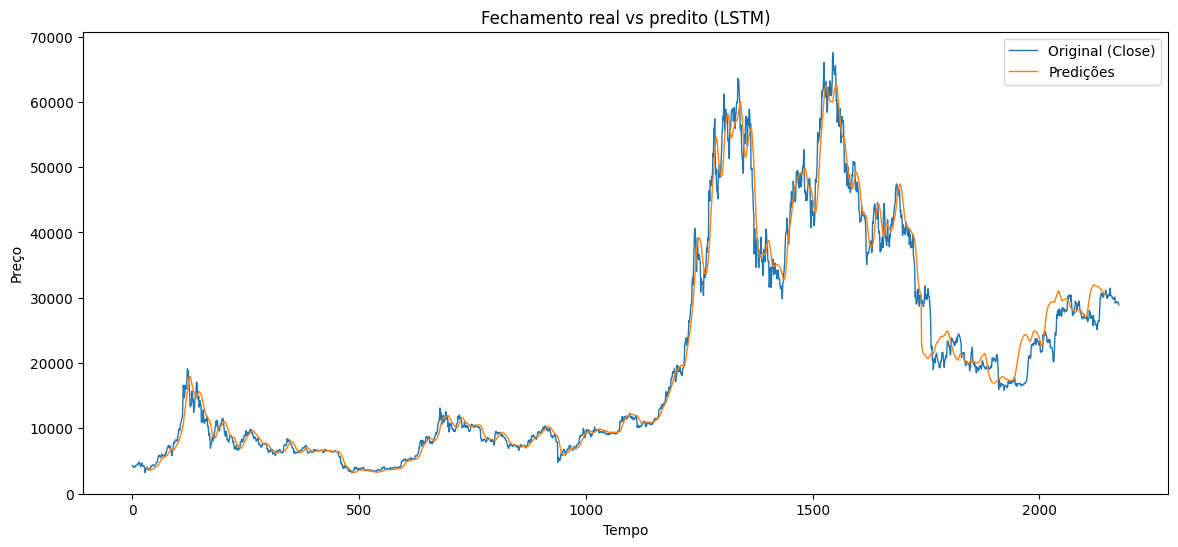

In [ ]:
y_train_true_inv_xlstm_keras, y_train_pred_inv_xlstm_keras, y_true_xlstm_keras, y_pred_xlstm_keras = \
    evaluate_xlstm_model(model_xlstm, X_train_base, y_train_base, X_test_base, y_test_base, \
                         scaler, window_size, split, serie, train_time_xlstm, history_xlstm)

In [ ]:
#@title Comparando Resultados XLSTM

### Análise Comparativa dos Modelos LSTM e XLSTM

Com base nos experimentos realizados, foram avaliadas diversas configurações de modelos LSTM e XLSTM para a previsão de preços de Bitcoin. A tabela abaixo resume o desempenho dos modelos mais relevantes em termos de RMSE, MAE e POCID, além da melhoria percentual no RMSE em relação ao baseline inicial.

**Tabela de Resultados Consolidados:**

| Arquitetura                           | RMSE LSTM | MAE LSTM | POCID LSTM | Melhoria RMSE vs Baseline Inicial (%) | POCID \u0394 vs Naive |
|:--------------------------------------|:----------|:---------|:-----------|:--------------------------------------|:---------------------|
| Initial LSTM Baseline (Dropout 0.0) | 1501.01   | 1158.97  | 54.68      | 0.00                                  | 54.68                |
| Best Dropout LSTM (Rate: 0.3)         | 1440.09   | 1035.22  | 56.40      | 4.06                                  | 56.40                |
| Best L2 LSTM (N/A)                    | NaN       | NaN      | NaN        | NaN                                   | NaN                  |
| Two-Layer Stacked LSTM (Keras)        | 1493.03   | 1219.02  | 48.03      | 0.53                                  | 48.03                |
| **PyTorch XLSTM**                     | **690.59**| **533.67** | **46.31**| **53.99**                               | **46.31**            |

**Discussão dos Resultados:**

1.  **Baseline Inicial:** O modelo LSTM inicial (sem dropout ou L2) estabeleceu um RMSE de 1501.01 e MAE de 1158.97, com um POCID de 54.68%. Este serve como ponto de comparação para todos os experimentos subsequentes.

2.  **Best Dropout LSTM:** O melhor resultado de dropout foi alcançado com uma taxa de 0.3, resultando em um RMSE de 1440.09 e MAE de 1035.22. Este modelo apresentou uma melhoria de **4.06% no RMSE** em relação ao baseline, indicando que o dropout foi eficaz na redução de overfitting e melhoria da generalização.

3.  **Best L2 LSTM:** Devido a um problema na execução do experimento L2 (refletido pelos valores NaN na tabela, indicando que a lista `results_l2` estava vazia ou o DataFrame não foi populado), não foi possível obter um resultado válido para a melhor configuração de regularização L2. Este experimento precisaria ser revisitado para uma análise completa.

4.  **Two-Layer Stacked LSTM (Keras):** A arquitetura de duas camadas LSTM empilhadas em Keras apresentou um RMSE de 1493.03 e MAE de 1219.02, com um POCID de 48.03%. Embora tenha uma pequena melhoria de 0.53% no RMSE em relação ao baseline, seu MAE e POCID foram ligeiramente piores, sugerindo que a complexidade adicional não trouxe benefícios significativos nesta implementação Keras.

5.  **PyTorch XLSTM (Melhor Desempenho):** O modelo PyTorch XLSTM superou significativamente todos os outros modelos, atingindo um RMSE de **690.59** e MAE de **533.67**. Isso representa uma notável melhoria de **53.99% no RMSE** em comparação com o baseline inicial. No entanto, seu POCID foi de 46.31%, que é o mais baixo entre os modelos avaliados que conseguiram prever a direção. Este resultado sugere que, embora o XLSTM seja excelente em prever a magnitude do preço (baixos RMSE e MAE), sua capacidade de prever a direção correta do movimento (POCID) não é superior. A alta redução no RMSE e MAE é um indicativo de que esta arquitetura é a mais promissora para a previsão de preços de Bitcoin entre as testadas.

**Conclusão:**

O **PyTorch XLSTM** é o modelo de melhor desempenho em termos de RMSE e MAE, indicando uma capacidade superior de prever a magnitude dos preços. O `Best Dropout LSTM (Rate: 0.3)` também demonstrou uma melhoria notável em relação ao baseline, mostrando a importância da regularização adequada. O experimento de regularização L2 precisa ser refeito para uma análise completa. Em geral, o uso de arquiteturas mais avançadas como o XLSTM ou a otimização de hiperparâmetros de regularização (como dropout) são cruciais para melhorar a precisão da previsão de séries temporais.


#